Notebook para fazer visualizações e comparações entre distribuições CPRI e Poisson.

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, errno
import sys
from math import sqrt

#Settings
PRED_ALG = 'mlp'
BASE_DIR = 'test_poissonPG_IPACT_pred_{}'.format(PRED_ALG)
NUMBER_OF_OLTs = 1
NUMBER_OF_ONUs = 20
DISTANCE = 20 #Distance in kilometers
TRAFFIC = "poisson"
DBA_ALG = "ipact_pred"


IPACT_Pred_r2_medio = {}
IPACT_Pred_mse_medio = {}
IPACT_Pred_r2_std = {}
IPACT_Pred_mse_std = {}
#load % values which represents each exponent
#loads = [25,31,37,43,50,56,62,68,75,81,87,93]
loads = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99]
#pkt arrival distribution exponents
#exponents = [1160, 1450, 1740, 2030, 2320, 2610, 2900, 3190, 3480, 3770, 4060, 4350]
exponents = [0.01, 0.05, 0.1, 0.20, 0.30, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
# To do a complete test: uncomment the line below
#seeds = [20,30,40,50,60,70,80,90,100,110] #random seeds
# To do a FAST test: uncomment the line below
seeds = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
#parameters = [{'w':12, 'p':1}]
parameters = [{'w':25, 'p':1}]
#parameters = [{'w':30, 'p':2}, {'w':20, 'p':2}, {'w':25, 'p':2}, {'w':15, 'p':2}]
#PKT_SIZES = ['1536000']
#PKT_SIZES = ['768000']
PKT_SIZES = ['768000', '1536000', '3072000', '3840000']

for size in PKT_SIZES:
    IPACT_Pred_r2_medio[size] = {}
    IPACT_Pred_mse_medio[size] = {}
    IPACT_Pred_r2_std[size] = {}
    IPACT_Pred_mse_std[size] = {}

In [122]:
def calculateT_student(vetor_medias, f_degrees):
    table_const = 2.262
    media_final = np.mean(vetor_medias)
    std_final = np.std(vetor_medias)
    interval_amp = table_const*std_final/(sqrt(f_degrees))
    
    structured_resp = {'t-test amp': interval_amp, 't-test interval': [media_final-interval_amp, media_final+interval_amp]}

    return structured_resp

Leitura dos dados gerados em tráfego Poisson e criação de dataframe (Alterado para lidar com múltiplas seeds e combinações de 'w' e 'p').

In [123]:
for params in parameters:
    for exp in exponents:
        for payload_size in PKT_SIZES:
            ipact_mean = []
            ipact_std = []
            for seed in seeds:
                df_tmp = pd.read_csv("{}/{}km/{}/csv/metrics/{}-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-w{}-p{}-s{}-metrics.csv".format(BASE_DIR, DISTANCE, payload_size, DBA_ALG, DISTANCE,
                                                                                                    NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                    TRAFFIC, exp, payload_size, params['w'], params['p'], seed))
                ipact_mean.append(df_tmp['r2_score'].mean())
                ipact_std.append(df_tmp['r2_score'].std())
                
            media = np.mean(ipact_mean)
            #std = np.mean(std_pkt_loss)
            t_test_results = calculateT_student(ipact_mean, 10)
            std = t_test_results['t-test amp']
            IPACT_Pred_r2_medio[payload_size][exp] = media
            IPACT_Pred_r2_std[payload_size][exp] = std

ipact_df_pr_r2medias = pd.DataFrame(IPACT_Pred_r2_medio)
ipact_df_pr_r2stds = pd.DataFrame(IPACT_Pred_r2_std)

In [124]:
ipact_df_pr_r2medias

,768000,1536000,3072000,3840000
0.01,NaN,NaN,NaN,NaN
0.05,0.670903,0.659309,0.657340,0.651918
0.10,0.635405,0.632698,0.626204,0.631131
0.20,0.606004,0.607311,0.611394,0.625769
0.30,0.591208,0.588401,0.606059,0.621646
0.40,0.572596,0.583482,0.612303,0.624632
0.50,0.561203,0.577762,0.619664,0.626161
0.60,0.555831,0.585083,0.622561,0.626789
0.70,0.554916,0.584727,0.618189,0.625456
0.80,0.550312,0.580592,0.622069,0.627537


MSEs

In [125]:
for params in parameters:
    for exp in exponents:
        for payload_size in PKT_SIZES:
            ipact_mean = []
            ipact_std = []
            for seed in seeds:
                df_tmp = pd.read_csv("{}/{}km/{}/csv/metrics/{}-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-w{}-p{}-s{}-metrics.csv".format(BASE_DIR, DISTANCE, payload_size, DBA_ALG, DISTANCE,
                                                                                                    NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                    TRAFFIC, exp, payload_size, params['w'], params['p'], seed))
                ipact_mean.append(df_tmp['mse'].mean())
                ipact_std.append(df_tmp['mse'].std())
                
            media = np.mean(ipact_mean)
            #std = np.mean(std_pkt_loss)
            t_test_results = calculateT_student(ipact_mean, 10)
            std = t_test_results['t-test amp']
            IPACT_Pred_mse_medio[payload_size][exp] = media
            IPACT_Pred_mse_std[payload_size][exp] = std

ipact_df_pr_msemedias = pd.DataFrame(IPACT_Pred_mse_medio)
ipact_df_pr_msestds = pd.DataFrame(IPACT_Pred_mse_std)

In [126]:
ipact_df_pr_msemedias

,768000,1536000,3072000,3840000
0.01,NaN,NaN,NaN,NaN
0.05,0.111553,0.121886,0.118558,0.122128
0.10,0.037593,0.036901,0.038718,0.038046
0.20,0.011139,0.011330,0.013161,0.017213
0.30,0.005802,0.006212,0.013507,0.020019
0.40,0.003814,0.004990,0.014415,0.020632
0.50,0.002916,0.005082,0.014576,0.021300
0.60,0.002538,0.005030,0.014715,0.021703
0.70,0.002372,0.005306,0.015472,0.022300
0.80,0.002299,0.005376,0.015262,0.022295


Abertura de figura e edição de título.

<Figure size 640x480 with 0 Axes>

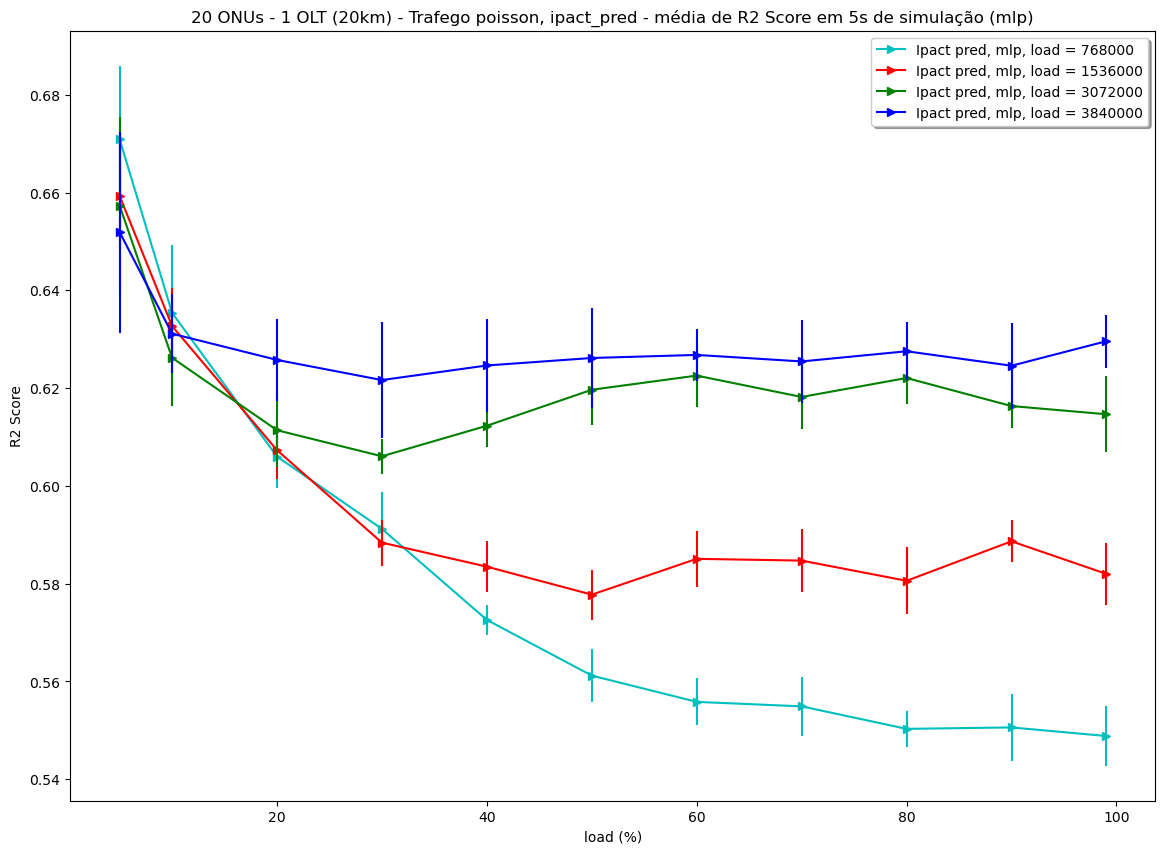

In [127]:
plt.clf()
plt.figure(figsize=(14, 10))
title = "{} ONUs - {} OLT ({}km) - Trafego {}, {} - média de R2 Score em 5s de simulação ({})".format(NUMBER_OF_ONUs, NUMBER_OF_OLTs, DISTANCE, TRAFFIC, DBA_ALG, PRED_ALG)
plt.title(title)
plt.xlabel("load (%)")
plt.ylabel("R2 Score")
plt.yscale('linear')
cmap = plt.get_cmap('gnuplot')
colors = ['c', 'r', 'g', 'b']
#plt.errorbar(loads, ipact_df.iloc[0].values,ipact_df.iloc[1].values,color="k", linestyle='None')
#plt.plot(loads, ipact_df.iloc[0], 'o-', color="k",label="IPACT")

i=0
for payload_size in PKT_SIZES:
    aux_df = pd.DataFrame(ipact_df_pr_r2medias[payload_size])
    aux_label = "Ipact pred, {}, load = {}".format(PRED_ALG, payload_size)
    media_delay = np.array(aux_df.iloc[:,0])
    aux_df = pd.DataFrame(ipact_df_pr_r2stds[payload_size])
    std_delay = np.array(aux_df.iloc[:,0])
    #print(std_delay)
    #plt.errorbar(loads, media_delay, std_delay, color=colors[i], linestyle='None')
    plt.plot(loads, media_delay, '->', color=colors[i], label=aux_label)
    plt.errorbar(loads, media_delay, std_delay, color=colors[i], linestyle='None')
    
    i += 1
      
plt.legend(loc='best', shadow=True)
plt.savefig(title)
plt.show()


<Figure size 640x480 with 0 Axes>

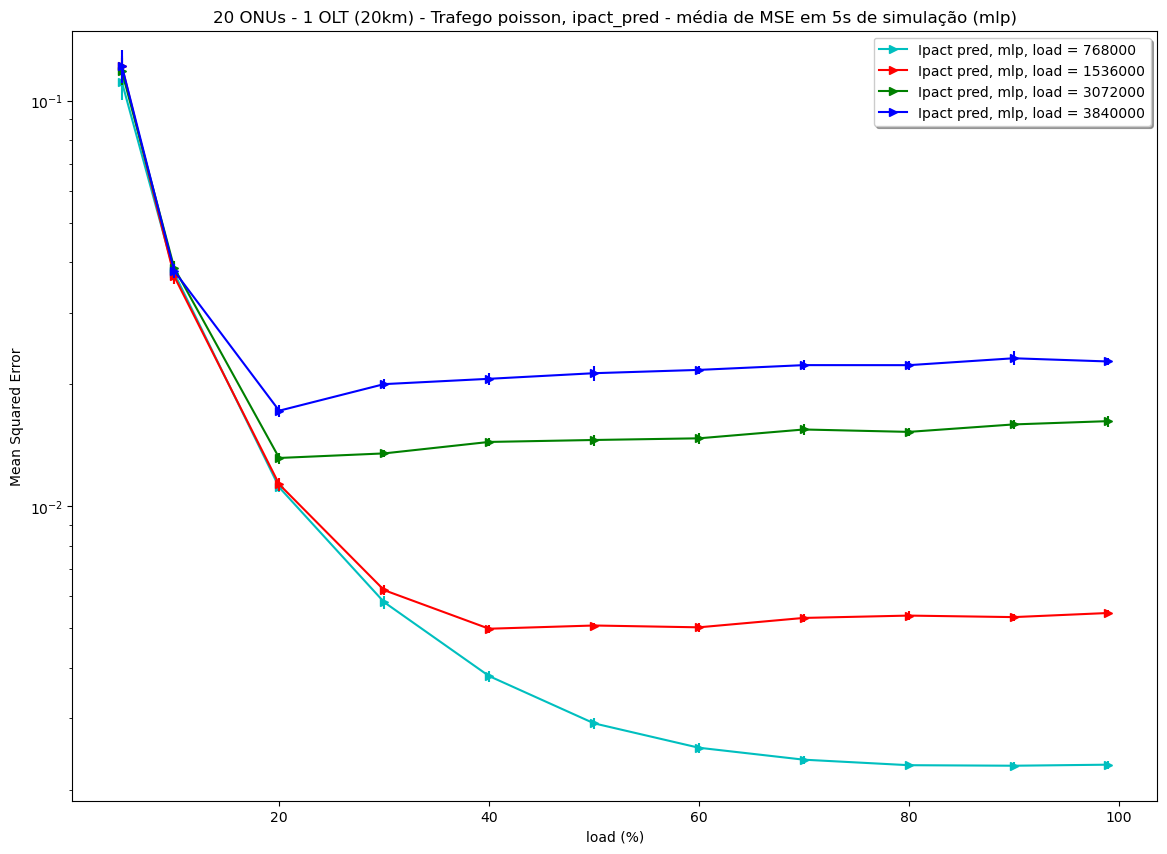

In [128]:
plt.clf()
plt.figure(figsize=(14, 10))
title = "{} ONUs - {} OLT ({}km) - Trafego {}, {} - média de MSE em 5s de simulação ({})".format(NUMBER_OF_ONUs, NUMBER_OF_OLTs, DISTANCE, TRAFFIC, DBA_ALG, PRED_ALG)
plt.title(title)
plt.xlabel("load (%)")
plt.ylabel("Mean Squared Error")
plt.yscale('log')
cmap = plt.get_cmap('gnuplot')
colors = ['c', 'r', 'g', 'b']
#plt.errorbar(loads, ipact_df.iloc[0].values,ipact_df.iloc[1].values,color="k", linestyle='None')
#plt.plot(loads, ipact_df.iloc[0], 'o-', color="k",label="IPACT")

i=0
for payload_size in PKT_SIZES:
    aux_df = pd.DataFrame(ipact_df_pr_msemedias[payload_size])
    aux_label = "Ipact pred, {}, load = {}".format(PRED_ALG, payload_size)
    media_delay = np.array(aux_df.iloc[:,0])
    aux_df = pd.DataFrame(ipact_df_pr_msestds[payload_size])
    std_delay = np.array(aux_df.iloc[:,0])
    #print(std_delay)
    plt.plot(loads, media_delay, '->', color=colors[i], label=aux_label)
    plt.errorbar(loads, media_delay, std_delay, color=colors[i], linestyle='None')

    
    i += 1
      
plt.legend(loc='best', shadow=True)
plt.savefig(title)
plt.show()
